# Problème d'affectation - Enseignants & Lycées, Porto-Novo

## Contexte
Une université de la place doit affecter 4 enseignats vacataires à 4 établissements secondaires autour de Cotonou pour des cours de mathématiques.
Chaque enseignant a un coût de déplacement différent selon l'établissement.

**Objectif** : minimiser le coût total de déplacement.

## Modèle mathématique

Soit $x_{ij} \in \{0,1\}$ : 1 si l'enseignant $i$ est affecté à l'établissement $j$.

$$\min Z = \sum_{i}\sum_{j} c_{ij} \cdot x_{ij}$$

$$\sum_{j} x_{ij} = 1 \quad \forall i \qquad \text{(chaque enseignant a une seule affectation)}$$

$$\sum_{i} x_{ij} = 1 \quad \forall j \qquad \text{(chaque établissement reçoit un seul étudiant)}


In [1]:
# Les imports nécessaires
import pulp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Les agents et les tâches
enseignants    = ["Aicha", "Brice", "Céleste", "Darius"]
etablissements = ["Lycée Coulibaly", "CEG Akpakpa", "Lycée Béhanzin", "CEG Cadjèhoun"]

# Matrice des coûts (en FCFA de transport/semaine)
couts = {
    "Aicha"   : {"Lycée Coulibaly": 8000, "CEG Akpakpa": 5000, "Lycée Béhanzin": 9000,  "CEG Cadjèhoun": 3000},
    "Brice"   : {"Lycée Coulibaly": 6000, "CEG Akpakpa": 4000, "Lycée Béhanzin": 7000,  "CEG Cadjèhoun": 8000},
    "Céleste" : {"Lycée Coulibaly": 9000, "CEG Akpakpa": 11000,"Lycée Béhanzin": 4000,  "CEG Cadjèhoun": 6000},
    "Darius"  : {"Lycée Coulibaly": 7000, "CEG Akpakpa": 6000, "Lycée Béhanzin": 5000,  "CEG Cadjèhoun": 9000},
}

In [3]:
# Création du modèle
prob = pulp.LpProblem("Affectation_Benin", pulp.LpMinimize)

# Variables de décision
x = {
    i: {
        j: pulp.LpVariable(f"x_{i}_{j}", cat="Binary")
        for j in etablissements
    }
    for i in enseignants
}

# Fonction objectif
prob += pulp.lpSum(
    couts[i][j] * x[i][j]
    for i in enseignants
    for j in etablissements
), "Coût_total"

# Contraintes enseignants
for i in enseignants:
    prob += pulp.lpSum(x[i][j] for j in etablissements) == 1, f"Enseignant_{i}"

# Contraintes établissements
for j in etablissements:
    prob += pulp.lpSum(x[i][j] for i in enseignants) == 1, f"Etablissement_{j}"

print(f"{len(prob.constraints)} contraintes ajoutées")

8 contraintes ajoutées


In [4]:
# Résolution
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Statut et coût optimal
print(f"Statut : {pulp.LpStatus[prob.status]}")
print(f"Coût optimal : {pulp.value(prob.objective):,.0f} FCFA\n")

# Affectation optimale
print("Affectation optimale :")
for i in enseignants:
    for j in etablissements:
        if pulp.value(x[i][j]) == 1:
            print(f"  {i} → {j} : {couts[i][j]:,} FCFA")

Statut : Optimal
Coût optimal : 18,000 FCFA

Affectation optimale :
  Aicha → CEG Cadjèhoun : 3,000 FCFA
  Brice → CEG Akpakpa : 4,000 FCFA
  Céleste → Lycée Béhanzin : 4,000 FCFA
  Darius → Lycée Coulibaly : 7,000 FCFA


## Analyse des résultats

- Le coût optimal est **18,000 FCFA/semaine**
- Chaque enseignant est affecté à son établissement le moins coûteux 
  **compatible avec les contraintes** — ce n'est pas toujours le minimum 
  absolu de sa ligne
- Une approche naïve (chacun va à son minimum sans coordination) 
  aurait créé un conflit sur Lycée Béhanzin (Céleste et Darius) 
  et abouti au même coût ici — mais ce n'est pas toujours le cas

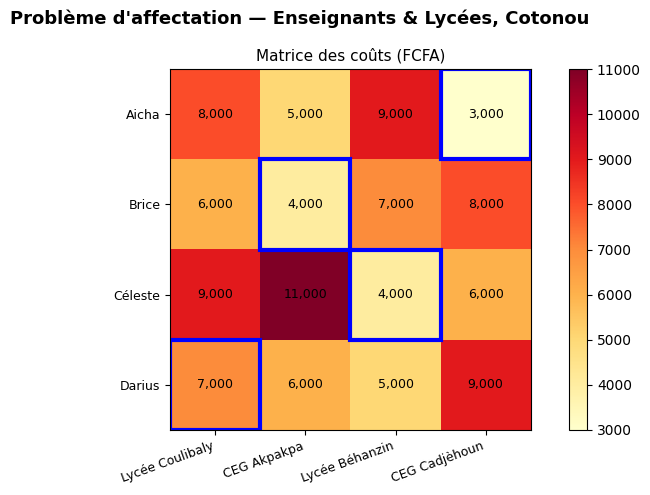

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 5))
fig.suptitle("Problème d'affectation — Enseignants & Lycées, Cotonou",
             fontsize=13, fontweight='bold')

ax1.set_title("Matrice des coûts (FCFA)", fontsize=11)

matrice = np.array([
    [couts[i][j] for j in etablissements]
    for i in enseignants
])

im = ax1.imshow(matrice, cmap="YlOrRd")
ax1.set_xticks(range(len(etablissements)))
ax1.set_yticks(range(len(enseignants)))
ax1.set_xticklabels(etablissements, rotation=20, ha='right', fontsize=9)
ax1.set_yticklabels(enseignants, fontsize=9)

for i in range(len(enseignants)):
    for j in range(len(etablissements)):
        ax1.text(j, i, f"{matrice[i,j]:,}",
                 ha='center', va='center', fontsize=9)

for i, ens in enumerate(enseignants):
    for j, etab in enumerate(etablissements):
        if pulp.value(x[ens][etab]) == 1:
            ax1.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor='blue', lw=3
            ))

plt.colorbar(im, ax=ax1)
plt.tight_layout()
plt.savefig("affectation_benin.png", dpi=150, bbox_inches='tight')
plt.show()